# Etapa 7 - Regularização e Overfitting (tarefa binária)

Compara duas redes de mesma arquitetura (`MLP(256,128,64)`):

- SEM regularização: sem dropout, sem L2, sem early stopping, treinada por muitas
  épocas → induz overfitting.
- COM regularização: Dropout(0.4) + L2(1e-3) + Early Stopping combinados.

Para tornar o overfitting visível (o treino completo tem ~152k amostras, o que já regulariza),
usa-se uma subamostra de 8.000 exemplos de treino; val e teste permanecem completos.
Lógica em `src/regularization.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, Markdown

import config
from src import regularization as rg

config.set_seeds()

C:\Users\Tobias Viero\AppData\Local\Temp\ipykernel_21020\2080049831.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Rodar o experimento (~1–2 min em CPU)

Treina as duas redes, salva a figura comparativa e a tabela.

In [2]:
comparison = rg.run(task="binary")
comparison


=== Etapa 7 — Regularização e overfitting (binary) ===


  treino (subamostra)=8000 | val=50736 | teste=50736
  treinando rede SEM regularização (sem dropout/L2/early stopping)...


  treinando rede COM regularização (Dropout + L2 + Early Stopping)...



             rede  dropout    l2  early_stopping  epocas  loss_treino  loss_val  loss_teste  roc_auc_treino  roc_auc_teste  f1_treino  f1_teste  gap_roc_auc_treino_teste
sem_regularizacao      0.0 0.000           False     200       0.0060    2.1435      2.1343          1.0000         0.7177     0.9943    0.3106                    0.2822
com_regularizacao      0.4 0.001            True      57       0.4908    0.5188      0.5196          0.8623         0.8103     0.4789    0.4335                    0.0520

Comparação salva em outputs/metrics/regularization_comparison.csv
Etapa 7 concluída.


,rede,dropout,l2,early_stopping,epocas,loss_treino,loss_val,loss_teste,roc_auc_treino,roc_auc_teste,f1_treino,f1_teste,gap_roc_auc_treino_teste
0,sem_regularizacao,0.0,0.000,False,200,0.0060,2.1435,2.1343,1.0000,0.7177,0.9943,0.3106,0.2822
1,com_regularizacao,0.4,0.001,True,57,0.4908,0.5188,0.5196,0.8623,0.8103,0.4789,0.4335,0.0520


## 2. Curvas treino × validação (lado a lado)

À esquerda, a loss de validação sobe enquanto a de treino cai (overfitting). À direita,
treino e validação caminham juntas até o early stopping.

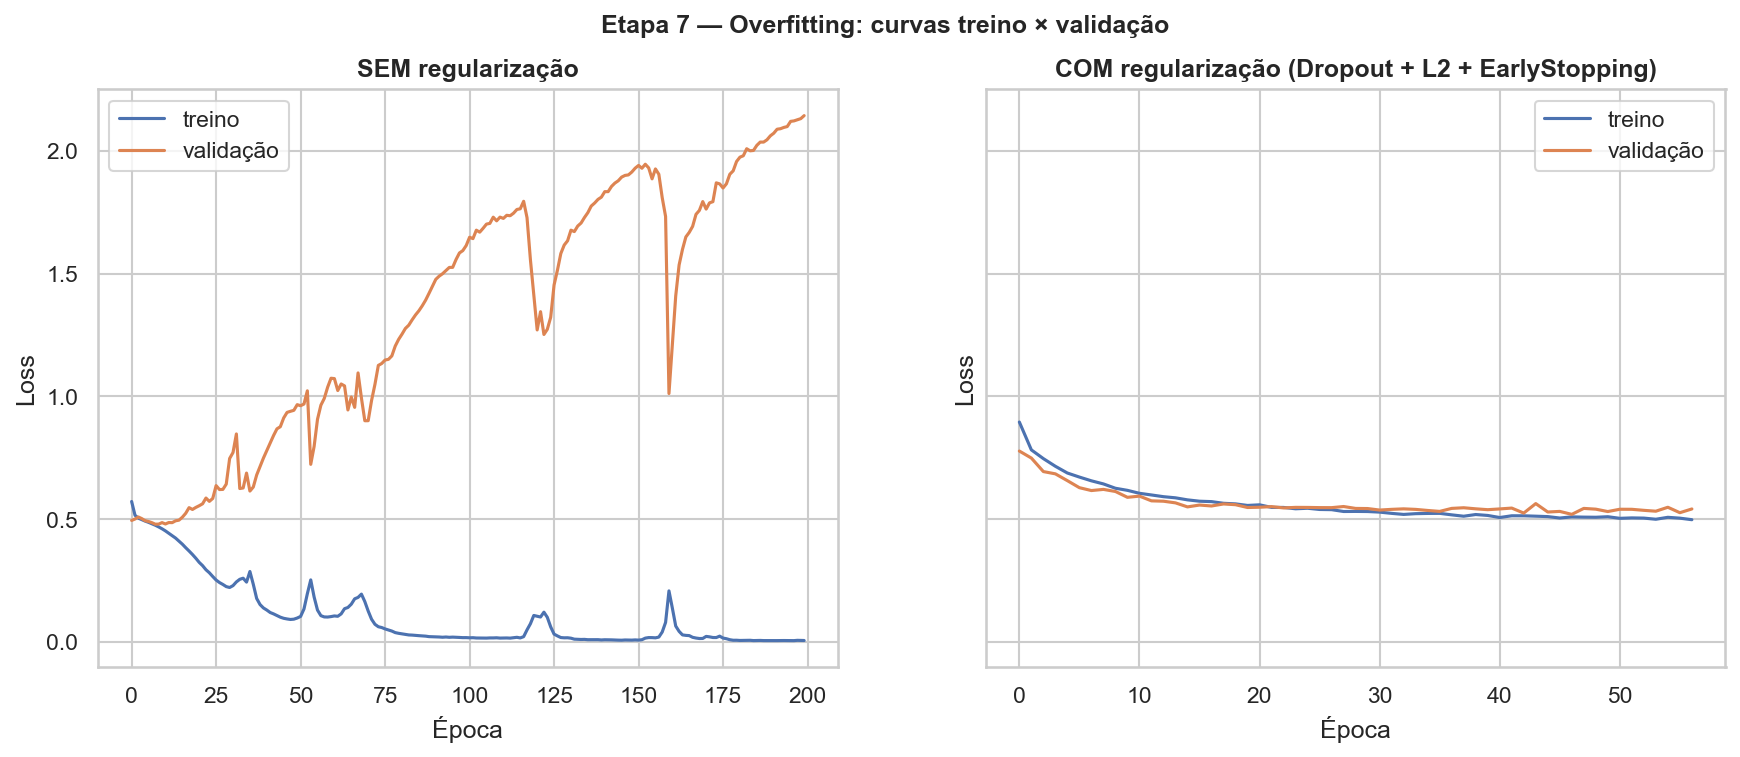

In [3]:
Image(str(config.FIGURES_DIR / "etapa7_curvas_comparacao.png"))